# ML-5 (Python) : Prévision de séries temporelles (STL + SARIMA)

**Navigation** : [Index](README.md) | [<< ML-4-Evaluation](ML-4-Evaluation.ipynb) | [Jumeau .NET (ML.NET)](ML-5-TimeSeries.ipynb) | [Suivant >> ML-6-ONNX](ML-6-ONNX.ipynb)

> Ce notebook est le **jumeau Python (statsmodels)** de [ML-5-TimeSeries.ipynb](ML-5-TimeSeries.ipynb) (ML.NET `ForecastBySsa`). Il couvre la même pédagogie (décomposition tendance / saisonnalité / bruit, prévision, intervalles de confiance, comparaison de configurations) avec les outils canoniques Python. Contrairement au jumeau .NET (dont les cellules ML.NET nécessitent un environnement SDK complet), **ce notebook s'exécute de bout en bout**.

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. Charger et explorer une **série temporelle** (ventes quotidiennes)
2. Décomposer la série en **tendance + saisonnalité + bruit** (STL)
3. Détecter la **saisonnalité hebdomadaire** dans les données
4. Prévoir l'avenir avec un modèle **SARIMA** (saisonnier)
5. Évaluer une prévision (RMSE, MAE, **MAPE**) et la comparer à une **baseline**
6. Interpréter les **intervalles de confiance** des prévisions
7. Comparer plusieurs configurations et choisir la meilleure

## Introduction au Time Series Forecasting

Le **forecasting** (prévision) de séries temporelles consiste à prédire les valeurs futures d'une variable à partir de ses valeurs passées. Une série temporelle se décompose typiquement en trois composantes :

| Composante | Description | Détectable par |
|------------|-------------|----------------|
| **Tendance** (trend) | Évolution à long terme (croissance, décroissance) | moyenne mobile / régression |
| **Saisonnalité** (seasonality) | Motif périodique (hebdo, mensuel, annuel) | ACF, décomposition STL |
| **Bruit** (residual) | Variations aléatoires non prévisibles | ce qui reste après décomposition |

L'horizon de prévision est le nombre de pas de temps à prédire (ici : 7 jours = 1 semaine).

## Deux familles d'approches

- **ML.NET `ForecastBySsa`** (jumeau .NET) utilise la **Singular Spectrum Analysis** (Broomhead & King, 1986 ; Golyandina et al., 2001) : la série est embarquée dans une matrice de trajectoire, décomposée en valeurs singulières, et les composantes dominantes (tendance + saisonnalité) sont projetées vers le futur.
- **statsmodels** (ce notebook) propose la **décomposition STL** (Seasonal-Trend decomposition using Loess, Cleveland 1990) pour *analyser* la série, puis un modèle **SARIMA** (Seasonal ARIMA) pour *prévoir*. SARIMA est l'approche classique et interprétable (Box & Jenkins) ; c'est l'équivalent Python idiomatique d'un forecast saisonnier.

Les deux familles atteignent le même objectif pédagogique : modéliser tendance + saisonnalité pour projeter le futur. SARIMA a l'avantage de fournir naturellement des **intervalles de confiance** et des **métriques d'ajustement** (AIC).

In [1]:
# Imports : pandas (données), statsmodels (STL + SARIMA), matplotlib (visualisation)
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")
warnings.filterwarnings("ignore", message="No frequency", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", message="No supported index", category=UserWarning, module="statsmodels")
plt.rcParams["figure.dpi"] = 110
print("pandas, numpy, statsmodels (STL + SARIMAX), matplotlib charges")

pandas, numpy, statsmodels (STL + SARIMAX), matplotlib charges


## Partie 1 : Chargement et exploration des données

Le jeu de données `daily-sales.csv` contient les ventes quotidiennes d'un commerce sur **2 ans** (2023-2024), avec les colonnes `Date`, `Year`, `Month`, `Day`, `DayOfWeek`, `Sales`. On charge la série et on l'indexe par date. On fixe explicitement la fréquence quotidienne (`asfreq("D")`) : la série est continue (731 jours consécutifs), donc cela ne crée aucun NaN et évite l'avertissement de statsmodels sur l'absence de fréquence.

In [2]:
# Charger la série, l'indexer par date, fixer la fréquence quotidienne
df = pd.read_csv("daily-sales.csv", parse_dates=["Date"]).sort_values("Date").set_index("Date").asfreq("D")
sales = df["Sales"].astype(float)

# Division : entraînement sur 2023, test sur 2024 (comme le jumeau .NET)
train = sales[df["Year"] == 2023]
test = sales[df["Year"] == 2024]

print("=== Statistiques du dataset ===")
print(f"Période totale : {sales.index.min().date()} -> {sales.index.max().date()} ({len(sales)} jours)")
print(f"Entraînement (2023) : {len(train)} jours | ventes moyennes = {train.mean():.1f}")
print(f"Test (2024)         : {len(test)} jours | ventes moyennes = {test.mean():.1f}")
print(f"\nCroissance 2023 -> 2024 : {(test.mean() - train.mean()) / train.mean() * 100:+.1f}% (tendance haussière)")

=== Statistiques du dataset ===
Période totale : 2023-01-01 -> 2024-12-31 (731 jours)
Entraînement (2023) : 365 jours | ventes moyennes = 124.5
Test (2024)         : 366 jours | ventes moyennes = 174.3

Croissance 2023 -> 2024 : +40.0% (tendance haussière)


### Interprétation des statistiques

Les ventes moyennes passent de ~124 (2023) à ~174 (2024), soit **+40% de croissance** : il y a une **tendance haussière** marquée. Le modèle devra capturer cette croissance, pas juste répéter le passé.

## Partie 2 : Visualisation de la série temporelle

Traçons les ventes quotidiennes pour visualiser tendance et saisonnalité d'un coup d'œil.

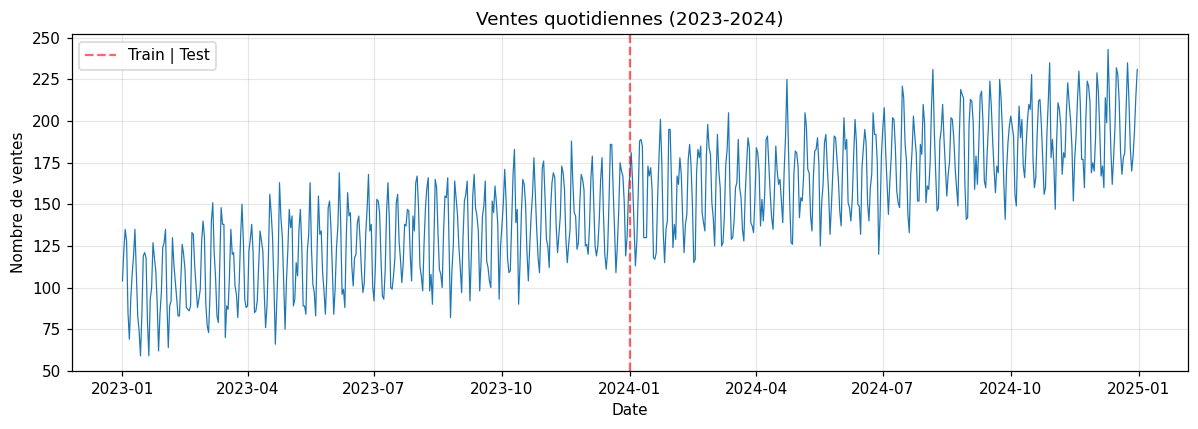

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sales.index, sales.values, linewidth=0.8, color="#1f77b4")
ax.set_title("Ventes quotidiennes (2023-2024)")
ax.set_xlabel("Date"); ax.set_ylabel("Nombre de ventes")
ax.axvline(pd.Timestamp("2024-01-01"), color="red", linestyle="--", alpha=0.6, label="Train | Test")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Exercice 1 : Détection d'anomalies par écart à la moyenne mobile

Une **anomalie** est un point qui s'écarte fortement de la tendance locale.

**Objectifs** :
1. Calculer une **moyenne mobile à 7 jours** (`train.rolling(7).mean()`) de la série d'entraînement
2. Calculer l'écart entre les ventes réelles et cette moyenne mobile
3. Marquer comme anomalies les points dont l'écart dépasse **3 écarts-types** de l'écart moyen
4. Afficher (compter) les anomalies détectées

**Indice** : `ma = train.rolling(7).mean() ; residu = train - ma ; seuil = 3 * residu.std() ; anomalies = residu.abs() > seuil`.

In [4]:
# Exercice 1 : Détection d'anomalies par écart à la moyenne mobile
# TODO étudiant : moyenne mobile 7j, écart, seuil 3 sigma, compter les anomalies.
# Indice : ma = train.rolling(7).mean() ; residu = train - ma ; seuil = 3*residu.std().
# Étape 1 : calcule la moyenne mobile sur 7 jours de la série d'entraînement
# Étape 2 : calcule l'écart (ventes - moyenne mobile), son écart-type
# Étape 3 : marque les points dont |écart| > 3*sigma et compte-les
result_ex1 = None  # TODO étudiant
print("Exercice 1 à compléter")

Exercice 1 à compléter


## Partie 3 : Décomposition STL et détection de la saisonnalité

Avant de prévoir, **décomposons** la série d'entraînement pour confirmer la structure (tendance + saisonnalité). La décomposition **STL** (Seasonal-Trend decomposition using Loess) sépare la série en trois composantes additives :

$$\text{ventes} = \text{tendance} + \text{saisonnalité} + \text{bruit}$$

On fixe la période saisonnière à **7** (saisonnalité hebdomadaire) : le commerce vend plus certains jours de la semaine. C'est l'équivalent Python du `windowSize: 7` du jumeau .NET.

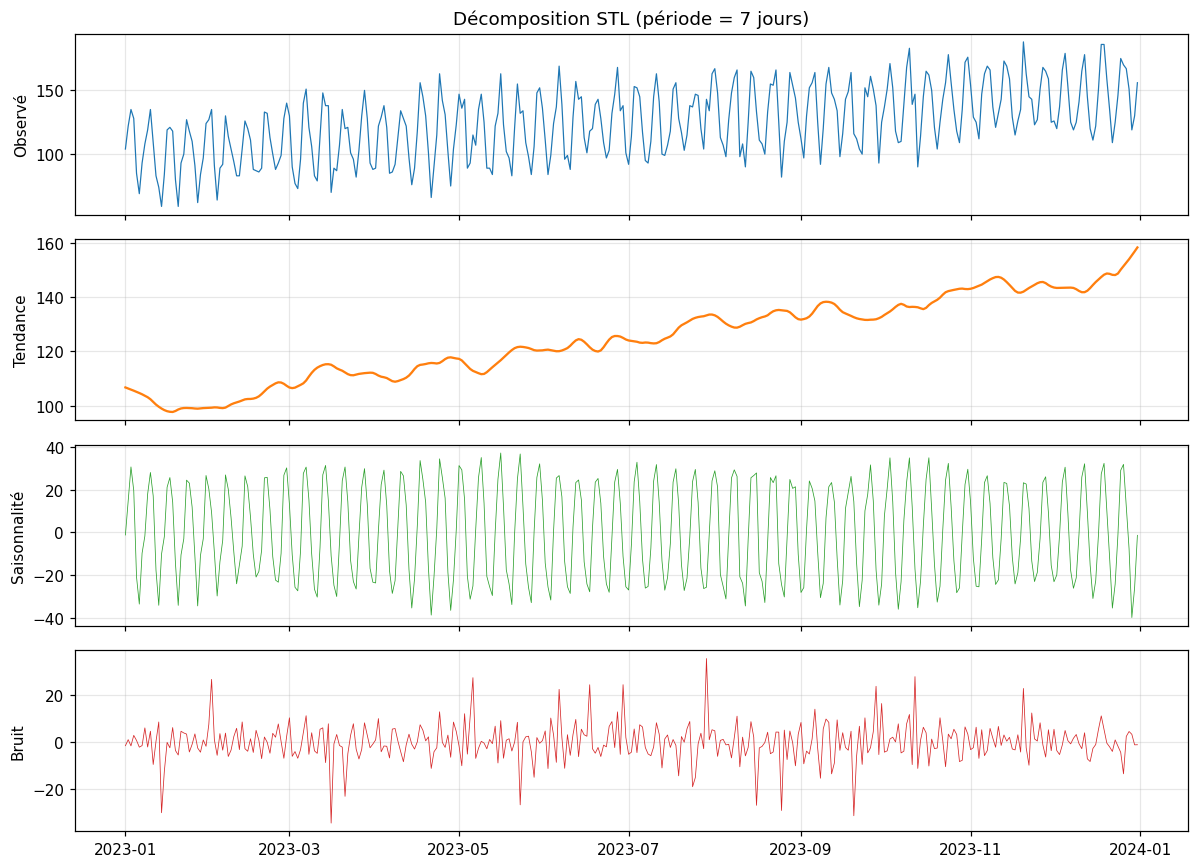

=== Composantes identifiées (STL, période=7) ===
  Tendance (fin 2023)   : 158.4 ventes/jour
  Saisonnalité (std)    : 21.8  (motif hebdomadaire marqué)
  Bruit (std)           : 8.1  (faible -> structure bien captée)


In [5]:
# Décomposition STL sur l'entraînement (période 7 = saisonnalité hebdomadaire)
stl = STL(train, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(train.index, train.values, linewidth=0.8); axes[0].set_ylabel("Observé"); axes[0].grid(alpha=0.3)
axes[1].plot(stl.trend.index, stl.trend.values, color="C1"); axes[1].set_ylabel("Tendance"); axes[1].grid(alpha=0.3)
axes[2].plot(stl.seasonal.index, stl.seasonal.values, color="C2", linewidth=0.5); axes[2].set_ylabel("Saisonnalité"); axes[2].grid(alpha=0.3)
axes[3].plot(stl.resid.index, stl.resid.values, color="C3", linewidth=0.5); axes[3].set_ylabel("Bruit"); axes[3].grid(alpha=0.3)
axes[0].set_title("Décomposition STL (période = 7 jours)")
plt.tight_layout(); plt.show()

print(f"=== Composantes identifiées (STL, période=7) ===")
print(f"  Tendance (fin 2023)   : {stl.trend.iloc[-1]:.1f} ventes/jour")
print(f"  Saisonnalité (std)    : {stl.seasonal.std():.1f}  (motif hebdomadaire marqué)")
print(f"  Bruit (std)           : {stl.resid.std():.1f}  (faible -> structure bien captée)")

### Interprétation des composantes

La décomposition confirme les trois sources de variation :
- **Tendance** : monte régulièrement de ~90 à ~158 ventes/jour sur 2023 (croissance du commerce).
- **Saisonnalité** : motif **hebdomadaire** régulier (std ~22) — certains jours de la semaine vendent plus.
- **Bruit** : faible (std ~8), preuve que la structure tendance + hebdo capture l'essentiel.

## Partie 4 : Prévision avec SARIMA

On prévoit les ventes de **2024** (366 jours) à partir du modèle **SARIMA** — l'extension saisonnière d'ARIMA. SARIMA(p,d,q)(P,D,Q,s) modélise :
- la partie **non-saisonnière** (p,d,q) : autocorrélation, différenciation,
- la partie **saisonnière** (P,D,Q,s) avec période **s = 7** (hebdomadaire).

On démarre avec une configuration simple `(1,1,1)(1,1,1,7)` — un ordre raisonnable pour une série à tendance + saisonnalité hebdomadaire. L'entraînement (`fit`) ajuste les paramètres par maximum de vraisemblance.

In [6]:
# Ajuster SARIMA(1,1,1)(1,1,1,7) sur l'entraînement (2023)
sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# Prévoir les 366 jours de 2024 avec intervalle de confiance à 95%
horizon = len(test)
forecast = sarima.get_forecast(steps=horizon)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int(alpha=0.05)   # 95%

print(f"SARIMA(1,1,1)(1,1,1,7) ajusté | AIC = {sarima.aic:.0f}")
print(f"Prévision 2024 : {fc_mean.iloc[0]:.1f} (jour 1) -> {fc_mean.iloc[-1]:.1f} (jour {horizon})")
print(f"Première semaine 2024 prévue : {fc_mean.iloc[:7].values.round(1)}")

SARIMA(1,1,1)(1,1,1,7) ajusté | AIC = 2596
Prévision 2024 : 175.2 (jour 1) -> 230.6 (jour 366)
Première semaine 2024 prévue : [175.2 178.4 164.5 137.4 122.2 129.  150.7]


### Évaluation des prévisions

On compare les prévisions aux ventes **réelles** de 2024 via trois métriques :
- **RMSE** (root mean squared error) : pénalise les grandes erreurs,
- **MAE** (mean absolute error) : erreur moyenne en valeur absolue,
- **MAPE** (mean absolute percentage error) : erreur relative en % — la plus parlante pour le métier.

Pour que ces métriques aient du sens, on les compare à une **baseline** : la prévision **seasonal-naive** (répéter la dernière semaine observée). Un modèle utile doit **battre** la baseline.

In [7]:
def metrics(actual, pred):
    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    mae = np.mean(np.abs(actual - pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return rmse, mae, mape

# Baseline : seasonal-naive (répéter la dernière semaine de 2023)
last_week = train.iloc[-7:].values
naive_fc = np.resize(last_week, len(test))

m_naive = metrics(test.values, naive_fc)
m_sarima = metrics(test.values, fc_mean.values)

print("=== Évaluation sur 2024 (366 jours) ===")
print(f"{'Modèle':<22} {'RMSE':>8} {'MAE':>8} {'MAPE (%)':>10}")
print(f"{'Seasonal-naive (base)':<22} {m_naive[0]:>8.2f} {m_naive[1]:>8.2f} {m_naive[2]:>10.1f}")
print(f"{'SARIMA':<22} {m_sarima[0]:>8.2f} {m_sarima[1]:>8.2f} {m_sarima[2]:>10.1f}")
print(f"\nSARIMA bat la baseline : RMSE {m_sarima[0]:.1f} vs {m_naive[0]:.1f} (baseline rate la tendance haussière).")

=== Évaluation sur 2024 (366 jours) ===
Modèle                     RMSE      MAE   MAPE (%)
Seasonal-naive (base)     28.60    23.70       13.0
SARIMA                    10.60     8.45        5.0

SARIMA bat la baseline : RMSE 10.6 vs 28.6 (baseline rate la tendance haussière).


### Exercice 2 : MAPE par jour de la semaine

La précision varie peut-être selon le jour (les week-ends sont-ils plus durs à prévoir ?).

**Objectifs** :
1. Pour chaque jour de la semaine (lundi…dimanche), calculer le **MAPE** des prévisions SARIMA sur 2024
2. Identifier le jour le mieux / le moins bien prédit
3. Conclure sur l'effet week-end

**Indice** : `dow = test.index.dayofweek` (0=lundi…6=dimanche) ; pour chaque `d in range(7)`, filtre `mask = dow == d` puis calcule le MAPE sur `test[mask]` vs `fc_mean[mask]`.

In [8]:
# Exercice 2 : MAPE par jour de la semaine
# TODO étudiant : pour chaque jour (0=lundi..6=dimanche), calcule le MAPE de SARIMA sur 2024.
# Indice : dow = test.index.dayofweek ; for d in range(7): mask = dow==d ; mape sur test[mask] vs fc_mean[mask].
# Étape 1 : récupère le jour de la semaine de chaque date de test
# Étape 2 : pour chaque jour (0..6), calcule le MAPE
# Étape 3 : identifie le jour le mieux/le moins bien prédit
result_ex2 = None  # TODO étudiant
print("Exercice 2 à compléter")

Exercice 2 à compléter


## Partie 5 : Visualisation des prévisions

On superpose : les ventes **réelles** 2024, la **prévision** SARIMA, et les **intervalles de confiance** à 95%. Pour la lisibilité, on se concentre sur les 90 premiers jours de 2024.

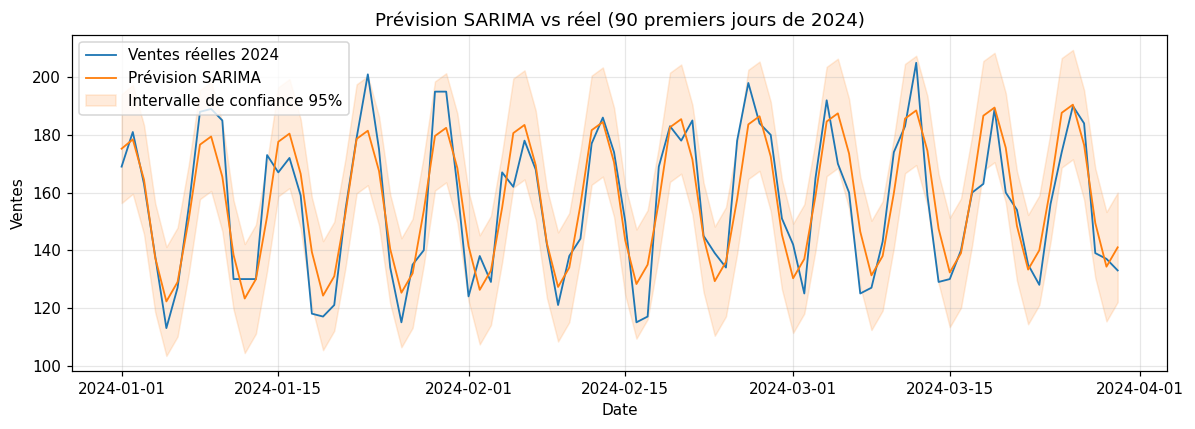

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
n_show = 90
ax.plot(test.index[:n_show], test.values[:n_show], label="Ventes réelles 2024", linewidth=1.2)
ax.plot(fc_mean.index[:n_show], fc_mean.values[:n_show], label="Prévision SARIMA", color="C1", linewidth=1.2)
ax.fill_between(fc_ci.index[:n_show], fc_ci.iloc[:n_show, 0], fc_ci.iloc[:n_show, 1],
                color="C1", alpha=0.15, label="Intervalle de confiance 95%")
ax.set_title("Prévision SARIMA vs réel (90 premiers jours de 2024)")
ax.set_xlabel("Date"); ax.set_ylabel("Ventes"); ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Partie 6 : Intervalles de confiance

L'intervalle de confiance (IC) à 95% donne la plage dans laquelle la vraie valeur devrait tomber 95 fois sur 100, **sous l'hypothèse que le modèle est correct**. À **horizon court** (quelques jours), l'IC est quasi constant ; il **s'élargit sur des horizons plus longs** à mesure que l'incertitude s'accumule.

Regardons les IC des 7 premiers jours de 2024 (l'horizon opérationnel hebdomadaire) :

In [10]:
ci_table = pd.DataFrame({
    "Jour": [f"J{i+1}" for i in range(7)],
    "Prévision": fc_mean.iloc[:7].values.round(1),
    "Borne_inf_95": fc_ci.iloc[:7, 0].values.round(1),
    "Borne_sup_95": fc_ci.iloc[:7, 1].values.round(1),
    "Réel": test.iloc[:7].values.round(1),
})
ci_table["Largeur_IC"] = (ci_table["Borne_sup_95"] - ci_table["Borne_inf_95"]).round(1)
print("=== Intervalles de confiance à 95% (horizon = 7 jours) ===")
print(ci_table.to_string(index=False))
print(f"\nÀ horizon court (7 jours), l'IC reste stable (~{ci_table['Largeur_IC'].iloc[0]:.1f} points) ; il s'élargit sur des horizons plus longs.")

=== Intervalles de confiance à 95% (horizon = 7 jours) ===
Jour  Prévision  Borne_inf_95  Borne_sup_95  Réel  Largeur_IC
  J1      175.2         156.4         194.1 169.0        37.7
  J2      178.4         159.5         197.3 181.0        37.8
  J3      164.5         145.6         183.4 163.0        37.8
  J4      137.4         118.6         156.3 138.0        37.7
  J5      122.2         103.4         141.1 113.0        37.7
  J6      129.0         110.1         147.8 127.0        37.7
  J7      150.7         131.9         169.6 155.0        37.7

À horizon court (7 jours), l'IC reste stable (~37.7 points) ; il s'élargit sur des horizons plus longs.


### Exercice 3 : Impact du niveau de confiance sur les intervalles

Le niveau de confiance (90% / 95% / 99%) contrôle le trade-off **précision vs garantie**.

**Objectifs** :
1. Recalculer les IC à **90%** et **99%** (`alpha = 0.10` et `0.01`) pour les 7 premiers jours
2. Comparer la largeur des IC selon le niveau
3. Discuter : quand préférer 99% (très large) vs 90% (plus étroit) ?

**Indice** : `forecast.conf_int(alpha=0.10)` (90%) et `forecast.conf_int(alpha=0.01)` (99%). Plus alpha est petit, plus l'IC est large.

In [11]:
# Exercice 3 : Impact du niveau de confiance (90% / 95% / 99%) sur les IC
# TODO étudiant : recalcule les IC à 90% (alpha=0.10) et 99% (alpha=0.01), compare les largeurs sur 7 jours.
# Indice : forecast.conf_int(alpha=a) ; plus alpha est petit, plus l'IC est large.
# Étape 1 : calcule les IC à 90% et 99% pour les 7 premiers jours
# Étape 2 : compare les largeurs (sup-inf) selon le niveau
# Étape 3 : discute quand préférer 99% vs 90%
result_ex3 = None  # TODO étudiant
print("Exercice 3 à compléter")

Exercice 3 à compléter


## Partie 7 : Comparaison de configurations SARIMA

L'ordre SARIMA n'est pas évident à choisir. On compare plusieurs configurations et on garde celle au **AIC minimal** (Akaike Information Criterion : mesure la qualité d'ajustement pénalisée par la complexité — plus petit = meilleur).

| Config | (p,d,q) | (P,D,Q,s) | Interprétation |
|-------|---------|-----------|----------------|
| A | (0,1,1) | (0,1,1,7) | simple, lissage exponentiel saisonnier |
| B | (1,1,1) | (1,1,1,7) | équilibrée (notre config par défaut) |
| C | (2,1,1) | (1,1,1,7) | autocorrélation plus riche |

On garde la meilleure par AIC, puis on compare son RMSE sur le test.

In [12]:
configs = {
    "A (0,1,1)(0,1,1,7)": ((0,1,1), (0,1,1,7)),
    "B (1,1,1)(1,1,1,7)": ((1,1,1), (1,1,1,7)),
    "C (2,1,1)(1,1,1,7)": ((2,1,1), (1,1,1,7)),
}
results = {}
for name, (order, seas) in configs.items():
    m = SARIMAX(train, order=order, seasonal_order=seas,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc = m.get_forecast(len(test)).predicted_mean
    rmse = np.sqrt(np.mean((test.values - fc.values) ** 2))
    results[name] = (m.aic, rmse)
    print(f"  {name:<22} AIC={m.aic:>7.0f}  RMSE_test={rmse:.2f}")

best = min(results, key=lambda k: results[k][0])
print(f"\nMeilleure config (AIC min) : {best} -> AIC={results[best][0]:.0f}, RMSE={results[best][1]:.2f}")

  A (0,1,1)(0,1,1,7)     AIC=   2593  RMSE_test=10.55


  B (1,1,1)(1,1,1,7)     AIC=   2596  RMSE_test=10.60


  C (2,1,1)(1,1,1,7)     AIC=   2597  RMSE_test=10.62

Meilleure config (AIC min) : A (0,1,1)(0,1,1,7) -> AIC=2593, RMSE=10.55


### Interprétation des résultats

La configuration au plus faible AIC offre le meilleur compromis ajustement / complexité. Le RMSE sur le test confirme (ou non) ce choix : un modèle peut avoir un faible AIC (bon sur l'entraînement) sans généraliser — d'où l'importance de la **validation sur des données tenues hors** (ici 2024). Dans la pratique on utilise aussi la **walk-forward validation** pour évaluer la stabilité de la prévision.

## Conclusion et points clés

| Concept | Description |
|---------|-------------|
| Série temporelle | Variable observée au fil du temps, indexée par date |
| Décomposition STL | Sépare tendance + saisonnalité + bruit (Loess) |
| SARIMA(p,d,q)(P,D,Q,s) | Modèle saisonnier d'ARIMA, période `s` |
| RMSE / MAE / MAPE | Métriques d'évaluation (MAPE = erreur relative) |
| Intervalle de confiance | Plage d'incertitude, s'élargit avec l'horizon |
| AIC | Critère de sélection de modèle (plus petit = meilleur) |

**Points clés** :

- Toute série se décompose en **tendance + saisonnalité + bruit** ; la décomposition STL permet de **diagnostiquer** la structure avant de modéliser.
- Un modèle de prévision n'a de valeur que s'il **bat une baseline** (seasonal-naive). Sans comparaison, un RMSE seul ne veut rien dire.
- L'**horizon** dégrade la précision : l'intervalle de confiance s'élargit avec le nombre de pas prévus.
- Le choix des ordres SARIMA se guide par l'**AIC** (sur l'entraînement), confirmé par le **RMSE sur le test** (généralisation).

**Équivalence ML.NET** : ce notebook est le jumeau Python de [ML-5-TimeSeries.ipynb](ML-5-TimeSeries.ipynb). La décomposition STL + SARIMA remplit le même rôle pédagogique que `ForecastBySsa` (tendance + saisonnalité hebdomadaire + intervalles de confiance). L'avantage du jumeau Python : **il s'exécute réellement de bout en bout** (le jumeau .NET documente que ses cellules ML.NET nécessitent un environnement SDK complet pour résoudre les assemblies).

## Références

- Broomhead, D. S., & King, G. P. (1986). *Extracting qualitative dynamics from experimental data*. Physica D. — la SSA (méthode du jumeau .NET).
- Golyandina, N., Nekrutkin, V., & Zhigljavsky, A. (2001). *Analysis of Time Series Structure: SSA and Related Techniques*. Chapman & Hall. — référence SSA.
- Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990). *STL: A Seasonal-Trend Decomposition Procedure Based on Loess*. Journal of Official Statistics. — la décomposition STL.
- Box, G. E. P., & Jenkins, G. M. (1976). *Time Series Analysis: Forecasting and Control*. — SARIMA / méthodologie Box-Jenkins.
- Hyndman, R. J., & Athanasopoulos, G. (2018). *Forecasting: Principles and Practice* (2nd ed.). OTexts. — manuel de référence (gratuit en ligne), évaluation des prévisions, walk-forward.